## 1. Introducción

### Este notebook realiza la exploración inicial, limpieza, preprocesamiento y construcción del dataset final para el análisis de reducción de dimensionalidad y clustering.

**Dataset utilizado:** *Viviendas_CPV_2024_SV.csv*

**Diccionario:** *Diccionario bases de datos - CPV 2024 SV.xlsx*

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option("display.max_columns", 120)

In [2]:
# 2. Cargar - forzar como texto columnas que no deben perder ceros
csv_path = "Viviendas_CPV_2024_SV.csv"
dic_path = "Diccionario bases de datos - CPV 2024 SV.xlsx"

# primero inspección rápida de encabezados
tmp = pd.read_csv(csv_path, nrows=5, low_memory=False)
print("Encabezados detectados (primeros):", list(tmp.columns)[:20])

Encabezados detectados (primeros): ['DEPTO', 'DEPTODESC', 'MUNIC', 'MUNICDESC', 'DISTO', 'DISTODESC', 'COD_PROP', 'COD_VIV', 'I01_IDEM_ESTRUC', 'V01_VIV', 'V01_1_VIV_PARTICULAR', 'V01_2_VIV_COLECTIVA', 'V02_VIV_OCUPACION', 'V2_1_VIV_OCUPADA', 'V2_2_VIV_DESOCUPADA', 'V03_VIV_PARED', 'V04_VIV_TECHO', 'V05_VIV_PISO', 'V06_VIV_CUARTOS', 'V07_VIV_TENENCIA']


In [3]:
# 3. Lista base de columnas que deben conservar ceros a la izquierda (según diccionario)
cols_string = [
    "DEPTO", "DEPTODESC", "MUNIC", "MUNICDESC",
    "DISTO", "DISTODESC", "COD_PROP", "COD_VIV",
    # si hay más identificadores los debemos seguir agrégando aquí
]

# Asegurar columnas que existan en el CSV
cols_string = [c for c in cols_string if c in tmp.columns]
dtype_dict = {c: str for c in cols_string}

# Cargar completo (forzando esas columnas a str)
df = pd.read_csv(csv_path, dtype=dtype_dict, low_memory=False)
print("Cargado:", df.shape)


Cargado: (2270026, 35)


### 4. Cargar diccionario y renombrar columnas (Ya que queremos nombres legibles)


In [5]:
# 4.1 cargar diccionario
dicc = pd.read_excel(dic_path, dtype=str)
dicc.columns = dicc.columns.astype(str).str.lower().str.strip()
print("Columnas diccionario:", list(dicc.columns))

# ajustar nombres de columnas del diccionario según tu archivo (ej: 'mnemónico', 'etiqueta')

col_codigo = None
col_desc = None
for c in dicc.columns:
    if "mnem" in c or "mnemónico" in c or "mnemónico" in c.lower():
        col_codigo = c
    if "etiqu" in c or "etiqueta" in c or "label" in c.lower():
        col_desc = c

# si no encontró, imprimir columnas para que corrijas

if col_codigo is None or col_desc is None:
    print("Revisá las columnas del diccionario y asigná manualmente. Columnas disponibles:", list(dicc.columns))
else:
    dicc[col_codigo] = dicc[col_codigo].astype(str).str.strip()
    dicc[col_desc] = dicc[col_desc].astype(str).str.strip()
    mapa = dict(zip(dicc[col_codigo], dicc[col_desc]))
    
    # Renombrar solo si los mnemónicos existen en df.columns
    
    mapa_filtrado = {k:v for k,v in mapa.items() if k in df.columns}
    df.rename(columns=mapa_filtrado, inplace=True)
    print("Renombradas (preview):", list(mapa_filtrado.items())[:10])


Columnas diccionario: ['nan', 'censo de vii población y vi vivienda 2024 \ndiccionario de datos - características de las viviendas', 'unnamed: 2', 'unnamed: 3', 'unnamed: 4', 'unnamed: 5', 'unnamed: 6', 'unnamed: 7', 'unnamed: 8']
Revisá las columnas del diccionario y asigná manualmente. Columnas disponibles: ['nan', 'censo de vii población y vi vivienda 2024 \ndiccionario de datos - características de las viviendas', 'unnamed: 2', 'unnamed: 3', 'unnamed: 4', 'unnamed: 5', 'unnamed: 6', 'unnamed: 7', 'unnamed: 8']


### 5. Tipos: detectar y convertir
- Convertimos a `string` los IDs/geo y a enteros las variables del cuestionario.
- Usamos pandas `Int64` (nullable) para no perder NaNs.


In [9]:
# 5.1 asegurar columnas-string (IDs/geo)
cols_geo = [c for c in cols_string if c in df.columns]
for c in cols_geo:
    df[c] = df[c].astype(str).str.zfill(df[c].str.len().max() if df[c].str.len().notna().any() else 0).str.strip()
print("Geo/ID strings:", cols_geo)

# 5.2 variables numéricas (todas las demás de cuestionario que empiezan con I o V)
# Heurística: columnas que empiezan por I or V o AREA/GHS...
candidate_num = [c for c in df.columns if (c.upper().startswith(("I","V")) or c.upper() in ["AREA","GHS_DUG_L1","GHS_DUG_L2","GHS_DUG_L3"])]
candidate_num = [c for c in candidate_num if c in df.columns]
print("Candidates numeric (count):", len(candidate_num))

# Convertir a Int64 (nullable) usando coerción
for c in candidate_num:
    df[c] = pd.to_numeric(df[c], errors="coerce").astype("Int64")


Geo/ID strings: ['DEPTO', 'DEPTODESC', 'MUNIC', 'MUNICDESC', 'DISTO', 'DISTODESC', 'COD_PROP', 'COD_VIV']
Candidates numeric (count): 27


### 6. Tratar códigos especiales: 99 y 9 => NaN donde corresponda


In [11]:
# 6.1 según tu lista: materiales y origen de agua usan 99 como 'no sabe'
cols_99 = ["V03_VIV_PARED","V04_VIV_TECHO","V05_VIV_PISO","V12_VIV_PROVIENE_AGUA","V12_1_VIV_ABASTO_AGUA"]
cols_99 = [c for c in cols_99 if c in df.columns]

for c in cols_99:
    # si la columna es Int64, convertir 99 -> NA
    df.loc[df[c] == 99, c] = pd.NA

# 6.2 códigos 9 como 'no sabe' en varias variables
cols_9 = [c for c in df.columns if df[c].dtype.name.startswith("Int") and (df[c].max(skipna=True) >= 9)]
# filtrar por variables que en diccionario usan 9 (ejemplo general)
for c in cols_9:
    df.loc[df[c] == 9, c] = pd.NA

print("Reemplazados códigos especiales. Ejemplos NA counts:")
print(df[candidate_num].isna().sum().sort_values(ascending=False).head(10))


Reemplazados códigos especiales. Ejemplos NA counts:
V01_2_VIV_COLECTIVA       2268976
V2_2_VIV_DESOCUPADA       1841081
V12_1_VIV_ABASTO_AGUA      731506
V09_VIV_USO_SANIT          535574
V12_VIV_PROVIENE_AGUA      514675
V03_VIV_PARED              484043
V08_VIV_TIPO_SANIT         480125
V07_VIV_TENENCIA           479712
V13_VIV_FUENTE_ENERGIA     478799
V04_VIV_TECHO              477871
dtype: int64


### 7. Variables seleccionadas para clustering (según tu esquema)
- Identificadores / geografía (mantener para agregaciones)
- Variables de clustering: (lista)


In [15]:
# 7.1 Definir variables finales para clustering + metadata
id_geo = [c for c in ["COD_VIV","COD_PROP","DEPTO","MUNIC","DISTO","AREA","GHS_DUG_L1","GHS_DUG_L2"] if c in df.columns]
clust_vars = [c for c in [
    "I01_IDEM_ESTRUC","V01_VIV","V01_1_VIV_PARTICULAR","V01_2_VIV_COLECTIVA",
    "V03_VIV_PARED","V04_VIV_TECHO","V05_VIV_PISO",
    "V06_VIV_CUARTOS","V17_VIV_NUM_HOGARES","V18_VIV_NUM_PERSONAS",
    "V07_VIV_TENENCIA",
    "V08_VIV_TIPO_SANIT","V09_VIV_USO_SANIT",
    "V11_VIV_AGUA","V12_VIV_PROVIENE_AGUA","V12_1_VIV_ABASTO_AGUA",
    "V10_VIV_AGUAS_GRISES",
    "V13_VIV_FUENTE_ENERGIA","V14_VIV_COMBUSTIBLE_COCINA",
    "V15_VIV_ELIM_BASURA","V16_VIV_OLLA_COMUN"
] if c in df.columns]

print("ID/geo:", id_geo)
print("Variables clustering (count):", len(clust_vars))


ID/geo: ['COD_VIV', 'COD_PROP', 'DEPTO', 'MUNIC', 'DISTO', 'AREA', 'GHS_DUG_L1', 'GHS_DUG_L2']
Variables clustering (count): 21


### 8. Resumen de nulos y decisión
- Mostramos % de faltantes por variable y decidimos imputación (media/mediana o moda) o exclusión.


In [17]:
# 8.1 missing summary (n y %)
miss = df[clust_vars].isna().sum().sort_values(ascending=False)
miss_pct = (miss / len(df) * 100).round(2)
pd.concat([miss, miss_pct.rename("pct")], axis=1).head(30)


,0,pct
V01_2_VIV_COLECTIVA,2268976,99.95
V12_1_VIV_ABASTO_AGUA,731506,32.22
V09_VIV_USO_SANIT,535574,23.59
V12_VIV_PROVIENE_AGUA,514675,22.67
V03_VIV_PARED,484043,21.32
V08_VIV_TIPO_SANIT,480125,21.15
V07_VIV_TENENCIA,479712,21.13
V13_VIV_FUENTE_ENERGIA,478799,21.09
V04_VIV_TECHO,477871,21.05
V05_VIV_PISO,477640,21.04


### 9. Decisiones de imputación (plantilla)
- Numéricas de capacidad: `V06, V17, V18` = imputer con median (o 0 si prefieres).
- Categóricas: imputar con moda (most_frequent) o nueva categoría `-1` para NA.


In [19]:
# 9.1 Guardar snapshot intermedio
df.to_csv("dataset_limpio.csv", index=False)
print("Guardado dataset_limpio.csv")


Guardado dataset_limpio.csv


### 10. Exploración rápida visual
- Histogramas y heatmap (solo numéricas). Para dataset grande, muestra 100k o menos.


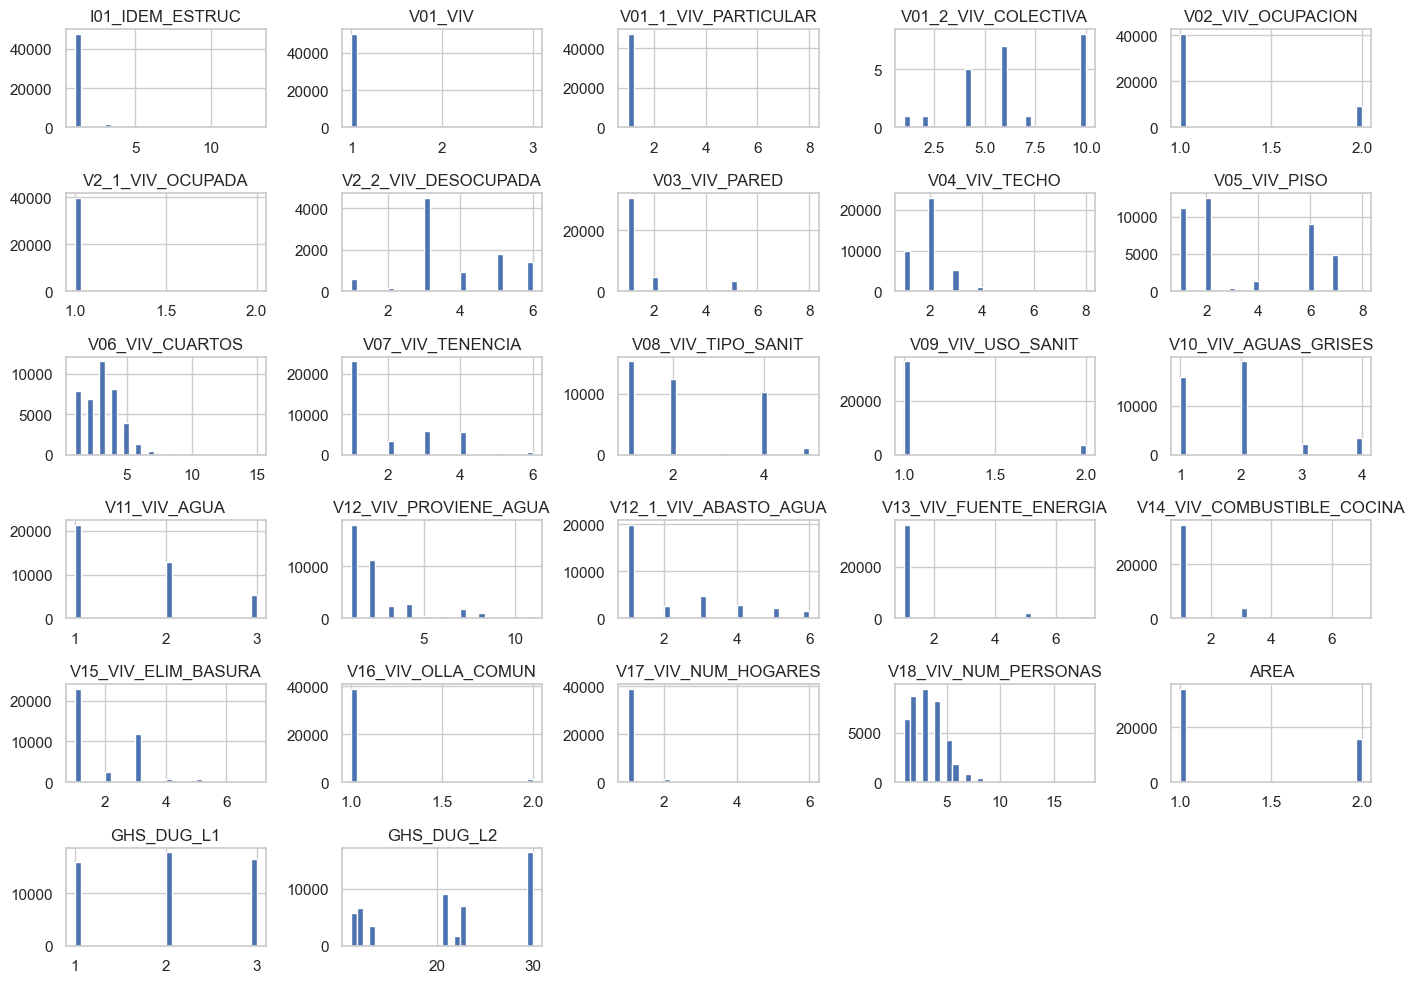

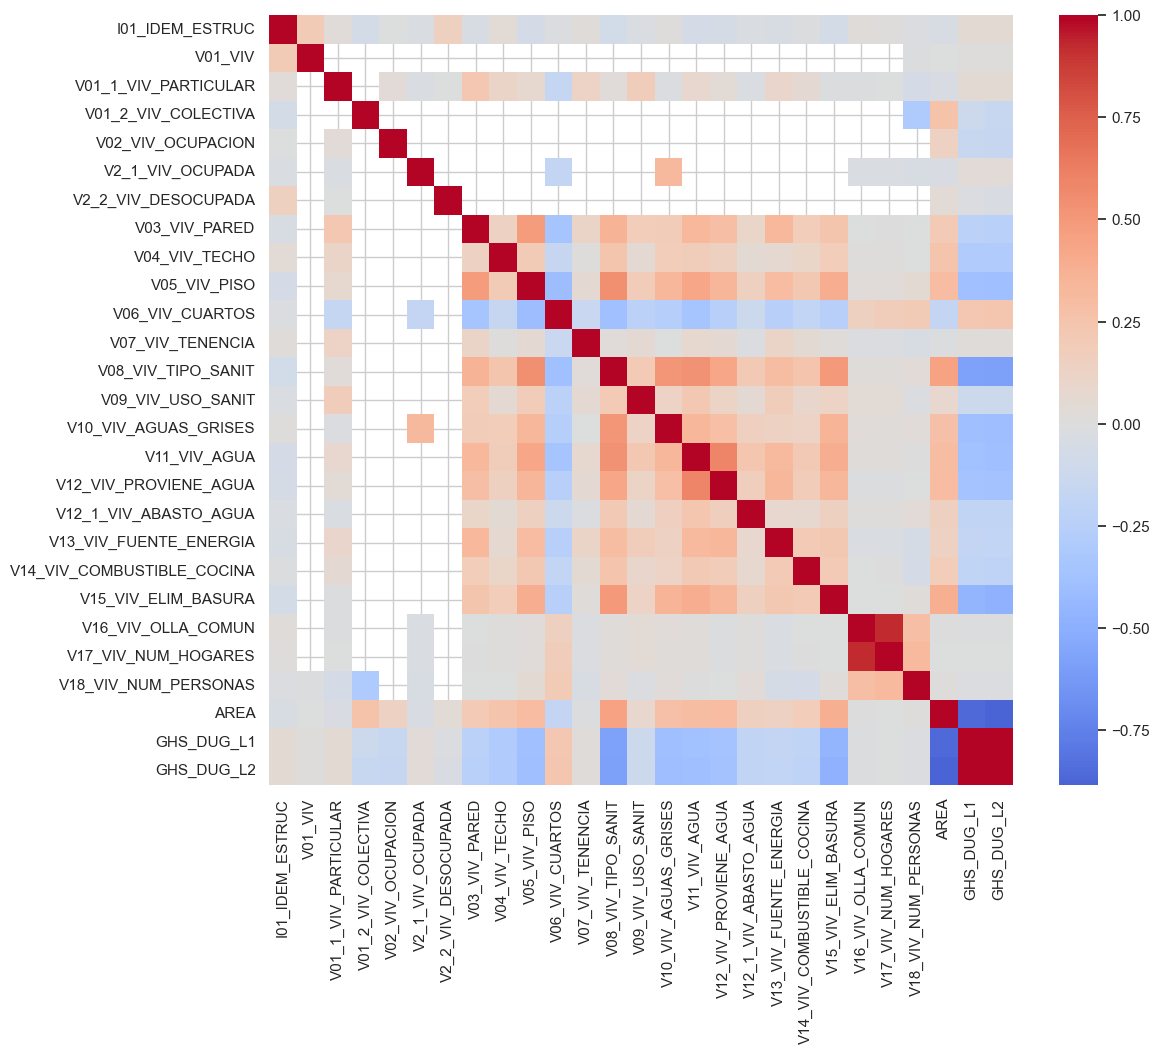

In [21]:
# 10.1 histogramas de numéricas (muestra si es muy grande)
sample_plot = df.sample(50000, random_state=42) if len(df) > 50000 else df
sample_plot.select_dtypes(include=["Int64","float","int"]).astype(float).hist(figsize=(14,10), bins=30)
plt.tight_layout()
plt.show()

# 10.2 heatmap de correlación (sobre muestra)
df_num = sample_plot.select_dtypes(include=["Int64","float","int"]).astype(float)
plt.figure(figsize=(12,10))
sns.heatmap(df_num.corr(), cmap="coolwarm", center=0)
plt.show()


**Fin del notebook 01.**  
Siguiente: 02_reduccion_dimensionalidad.ipynb (usaremos `dataset_limpio.csv`).